In [1]:
import jax
from jax import config
import jax.numpy as jnp
config.update("jax_enable_x64", True)  # do this at the very top


import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (5, 3)


from gaussed.domains import Euclidean
from gaussed.codomains import Codomain
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.probe import Probe, ProbeStack, as_stack
from gaussed.gp.kernels.rbf import RBFKernel
from gaussed.gp.kernels.matern import MaternKernel
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP, PosteriorGP
from gaussed.model import GPModel
from gaussed.utils.shape_helpers import pack_ev2mat
from gaussed.backends.base import ExactBackend

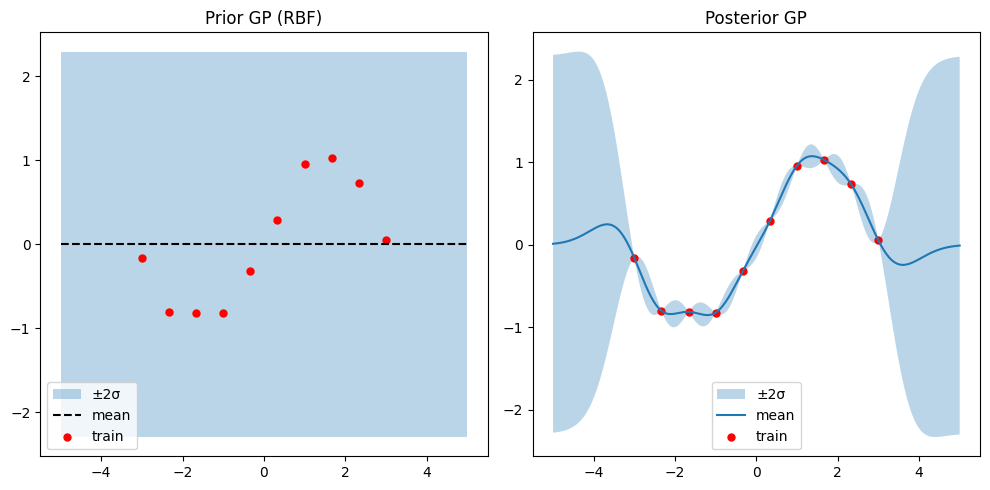

In [2]:
import jax
import jax.numpy as jnp

from gaussed.domains import Euclidean
from gaussed.codomains import Codomain
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.probe import Probe
from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP
from gaussed.model import GPModel
from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.backends.base import ExactBackend, SolverFns
from gaussed.backends.solvers.cholesky import chol_solve_hook, chol_sqrt_hook, chol_logdet_hook


solver_fns = SolverFns(chol_solve_hook(), chol_sqrt_hook(), chol_logdet_hook())

# --- GP prior ---
domain   = Euclidean((1,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.), amplitude=jnp.array(1.0))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 10).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood()
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


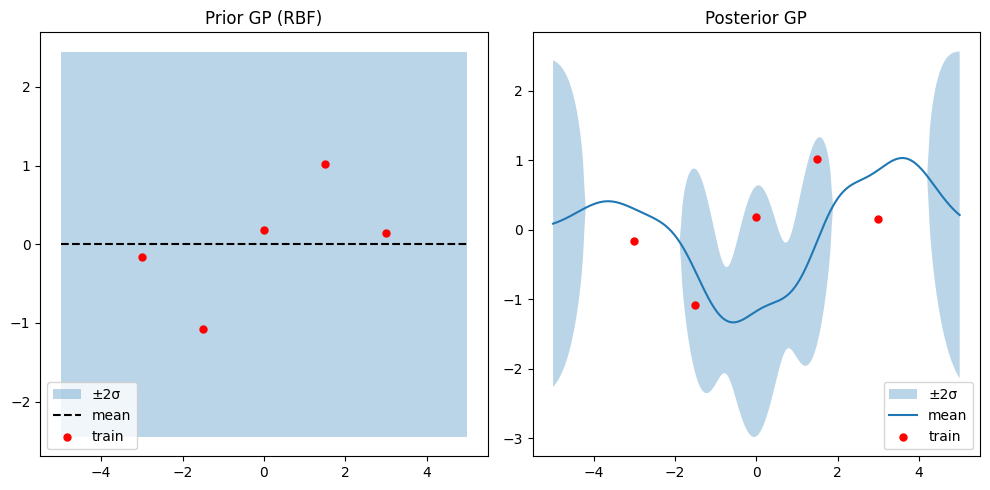

In [3]:
import jax
import jax.numpy as jnp

from gaussed.domains import Euclidean
from gaussed.codomains import Codomain
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.partial import Partial
from gaussed.gp.gp_ops.probe import Probe
from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP
from gaussed.model import GPModel
from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.likelihoods.gaussian_noise import DiagonalNoise

# --- GP prior ---
domain   = Euclidean((1,), robust=False)
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.3), amplitude=jnp.array(1.24751754))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)

# --- Data ---
key = jax.random.PRNGKey(0)
Xtr = jnp.linspace(-3.0, 3.0, 5).reshape(-1, 1)
y_clean = jnp.sin(Xtr).squeeze()
noise = 0.1
y = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# --- Probes ---
Ftr = Probe(ops=(Partial(0),), fnl=Eval(Xtr))
Xt = jnp.linspace(-5.0, 5.0, 300).reshape(-1, 1)
Fte = Probe(ops=(), fnl=Eval(Xt))

# --- Model / condition ---
lik = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post = model.condition(Ftr, y)

# --- Prior mean/var (for reference) ---
prior_mean = gp.mean_spec().eval(Xt)[:, 0]
prior_var  = jnp.diag(pack_ev2mat(gp.kernel_spec().k0(Xt, Xt), (1,), (1,)))

# --- Posterior mean/var ---
m_post = post.mean(Fte)
v_post = post.variance(Fte)

# --- Plot ---
xplot = Xt.squeeze()

plt.figure(figsize=(10,5))

# Prior
plt.subplot(1,2,1)
plt.title("Prior GP (RBF)")
plt.fill_between(xplot,
                 prior_mean - 2*jnp.sqrt(prior_var),
                 prior_mean + 2*jnp.sqrt(prior_var),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, prior_mean, "k--", label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

# Posterior
plt.subplot(1,2,2)
plt.title("Posterior GP")
plt.fill_between(xplot,
                 m_post.reshape(-1,) - 2*jnp.sqrt(v_post),
                 m_post.reshape(-1,) + 2*jnp.sqrt(v_post),
                 alpha=0.3, label="±2σ")
plt.plot(xplot, m_post, label="mean")
plt.scatter(Xtr.squeeze(), y, s=25, c="r", label="train")
plt.legend()

plt.tight_layout()
plt.show()


In [4]:
domain   = Euclidean((1,), robust=True)
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)
rbf_params = RBFParams(lengthscale=jnp.array(0.37816456), amplitude=jnp.array(1.24751754))
kernel   = RBFKernel(rbf_params)
backend = ExactBackend(solverfns=solver_fns)

gp = GP(domain, codomain, mean, kernel, backend)

ks = gp.kernel_spec()  


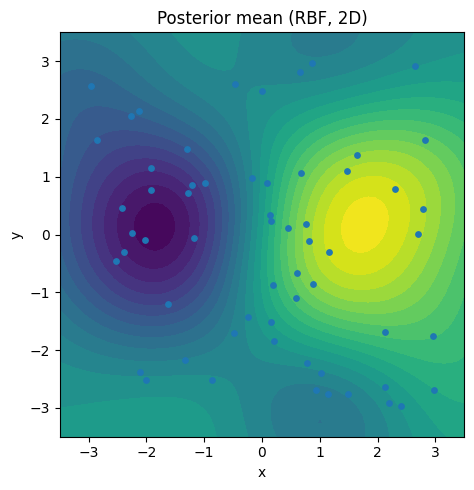

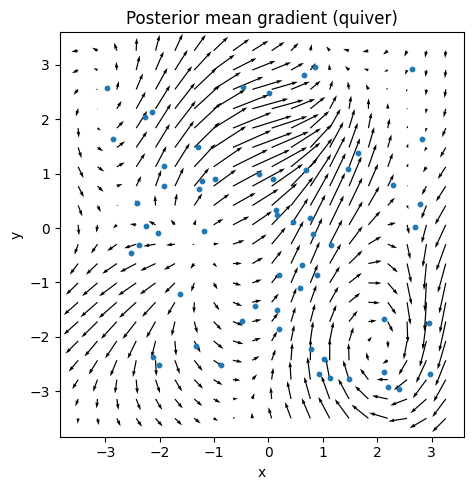

In [ ]:
from __future__ import annotations
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from gaussed.domains import Euclidean
from gaussed.codomains import Codomain
from gaussed.gp.gp_ops.point_eval import Eval
from gaussed.gp.gp_ops.probe import Probe
from gaussed.gp.kernels.rbf import RBFKernel, RBFParams
from gaussed.gp.means import ZeroMeanFun
from gaussed.gp.base import GP
from gaussed.model import GPModel
from gaussed.likelihoods.gaussian import GaussianLikelihood
from gaussed.gp.gp_ops.grad import Grad
from gaussed.backends.solvers.linear_solver import make_solver
from gaussed.backends.solvers.cholesky import chol_logdet_hook, chol_solve_hook, chol_sqrt_hook, cholesky_factor_from_op

from gaussed.backends.solvers.linear_solver import SolverFns, LinearSolverState


# ----------------------------
# GP prior (2D, with ARD)
# ----------------------------
domain   = Euclidean((2,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)

solver_fns = SolverFns(chol_solve_hook(), chol_sqrt_hook(), chol_logdet_hook())

backend = ExactBackend(solverfns=solver_fns)

# ARD lengthscales (ℓ_x, ℓ_y); amplitude = σ²
rbf_params = RBFParams(
    lengthscale=jnp.array([1.0, 0.7]),  # ARD
    amplitude=jnp.array(1.0),
)
kernel  = RBFKernel(rbf_params)

gp      = GP(domain, codomain, mean, kernel, backend)

# ----------------------------
# Synthetic 2D data
# ----------------------------
key = jax.random.PRNGKey(0)
n_tr = 60
Xtr = jax.random.uniform(key, (n_tr, 2), minval=-3.0, maxval=3.0)

def f_true(xy: jnp.ndarray) -> jnp.ndarray:
    # smooth, non-separable target
    x, y = xy[..., 0], xy[..., 1]
    return jnp.sin(x) * jnp.cos(0.8 * y) + 0.2 * x

y_clean = jax.vmap(f_true)(Xtr)
noise   = 0.1
y       = y_clean + noise * jax.random.normal(key, shape=y_clean.shape)

# ----------------------------
# Probes
# ----------------------------
Ftr   = Probe(ops=(), fnl=Eval(Xtr))                 # function values at Xtr
lik   = GaussianLikelihood(noise=DiagonalNoise(jnp.array([0.01])))
model = GPModel(gp=gp, likelihood=lik)
post  = model.condition(Ftr, y)

# Test grid for visualisation
nx = ny = 60
x1 = jnp.linspace(-3.5, 3.5, nx)
x2 = jnp.linspace(-3.5, 3.5, ny)
Xg1, Xg2 = jnp.meshgrid(x1, x2, indexing="xy")
Xgrid = jnp.stack([Xg1.ravel(), Xg2.ravel()], axis=1)     # (nx*ny, 2)

F_eval  = Probe(ops=(), fnl=Eval(Xgrid))                  # function probe
F_grad  = Probe(ops=(Grad(), ), fnl=Eval(Xgrid))  # gradient probe (∂/∂x, ∂/∂y)

# Posterior mean and gradient mean
m_post_grid = post.mean(F_eval).reshape(nx*ny)            # (N,)
g_post_grid = post.mean(F_grad).reshape(nx*ny, 2)         # (N, 2)

# ----------------------------
# Autodiff cross-check of gradient
# ----------------------------
# Make a scalar-valued mean function m(x) using the same machinery,
# then compare ∇m(x) from autodiff with the Gradient probe output.
def mean_at(x_row: jnp.ndarray) -> jnp.ndarray:
    Fe = Probe(ops=(), fnl=Eval(x_row[None, :]))
    return post.mean(Fe).squeeze()                        # scalar

grad_mean_at = jax.jit(jax.grad(mean_at))                 # (2,) -> (2,)

# # Check on a small random subset to keep it snappy
# idx = jnp.arange(Xgrid.shape[0])[:: max(1, (nx*ny)//2000)]
# Xchk = Xgrid[idx]
# g_ad  = jax.vmap(grad_mean_at)(Xchk)                      # (M, 2)
# g_gp  = g_post_grid[idx]                                  # (M, 2)
# grad_max_err = jnp.max(jnp.abs(g_ad - g_gp))
# print("Max |∇ mean| error vs autodiff:", float(grad_max_err))

# ----------------------------
# Plotting (two separate figures)
# ----------------------------
# 1) Posterior mean as filled contours
M = m_post_grid.reshape(ny, nx)
plt.figure(figsize=(6, 5))
plt.contourf(Xg1, Xg2, M, levels=25)
plt.scatter(Xtr[:, 0], Xtr[:, 1], s=15)
plt.title("Posterior mean (RBF, 2D)")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()

# 2) Gradient quiver (posterior mean gradient)
G = g_post_grid.reshape(ny, nx, 2)
step = max(1, nx // 20)   # thin arrows for clarity
plt.figure(figsize=(6, 5))
plt.quiver(Xg2[::step, ::step], Xg1[::step, ::step],
           G[::step, ::step, 1], G[::step, ::step, 0],
           angles="xy", scale_units="xy", scale=1.0)
plt.scatter(Xtr[:, 0], Xtr[:, 1], s=10)
plt.title("Posterior mean gradient (quiver)")
plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()


In [ ]:
op = Grad()

op.lift_right(ks, None).left_shape

(1,)

In [ ]:
ks = gp.kernel_spec()

In [ ]:
F_eval.kernel(F_grad, ks, None).shape

(3600, 3600, 1, 1, 2)

In [ ]:
F_grad.kernel(F_eval, ks, None).shape

(3600, 3600, 1, 2, 1)

In [ ]:
domain   = Euclidean((2,))
codomain = Codomain((1,))
mean     = ZeroMeanFun(domain, codomain)

solver_fns = SolverFns(chol_solve_hook(), chol_sqrt_hook(), chol_logdet_hook())

backend = ExactBackend(solverfns=solver_fns)

# ARD lengthscales (ℓ_x, ℓ_y); amplitude = σ²
rbf_params = RBFParams(
    lengthscale=jnp.array([1.0, 0.7]),  # ARD
    amplitude=jnp.array(1.0),
)
kernel  = RBFKernel(rbf_params)

gp      = GP(domain, codomain, mean, kernel, backend)


In [ ]:
ks = gp.kernel_spec()

In [ ]:
op = Grad()

op.map_left_shape(ks.left_shape, ks.domain)

(1, 2)

In [ ]:
F_grad.kernel(F_grad, ks, None)

ValueError: Expected (n,(1,)) or (1,) but got (3600, 2)

In [ ]:
F_eval.kernel(F_grad, ks, None)

ValueError: Expected (n,(1,)) or (1,) but got (3600, 2)

In [ ]:
F_grad.kernel(F_eval, ks, None)

ValueError: Expected (n,(1,)) or (1,) but got (3600, 2)

In [ ]:
nx

60

In [ ]:
post.

PosteriorGP(gp=GP(domain=Euclidean(shape=(2,), eps=0.0, robust=False), codomain=Codomain(output_shape=(1,)), mean=ZeroMeanFun(_domain=Euclidean(shape=(2,), eps=0.0, robust=False), _codomain=Codomain(output_shape=(1,))), kernel=RBFKernel(params=RBFParams(lengthscale=Array([1. , 0.7], dtype=float64), amplitude=Array(1., dtype=float64, weak_type=True)), lengthscale_transform=Positive(eps=1e-12), amplitude_transform=Positive(eps=1e-12), left_shape=(1,), right_shape=(1,)), backend=ExactBackend(solverfns=SolverFns(solve=<function chol_solve_hook.<locals>._solve at 0x7efb000b5a80>, sqrt=<function chol_sqrt_hook.<locals>._sqrt at 0x7efb000b6480>, logdet=<function chol_logdet_hook.<locals>._logdet at 0x7efb000b6a20>), solver_state=LinearSolverState(cache=None), linop_constructor=DenseGramConstructor(), quad=None, quad_xy=None, quad_x=None, quad_y=None), op_ctx=None), rep=KernelRep(_kernel_spec=KernelSpec(domain=Euclidean(shape=(2,), eps=0.0, robust=False), codomain=Codomain(output_shape=(1,)), 